# Analysis of Box Office Data

### Importing Libraries and Dataset

In [111]:
import numpy as np
import pandas as pd
pd.set_option('display.max_columns', None)
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
plt.style.use('ggplot')
from wordcloud import WordCloud
from collections import Counter
from nltk.corpus import stopwords
from nltk.util import ngrams
from sklearn.feature_extraction.text import TfidfVectorizer
import nltk
nltk.download('stopwords')
stop = set(stopwords.words('english'))
import xgboost as xgb


[nltk_data] Downloading package stopwords to C:\Users\Krishnansh
[nltk_data]     Verma\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [92]:
train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')

### Visualizing the Revenue Data

<Axes: >

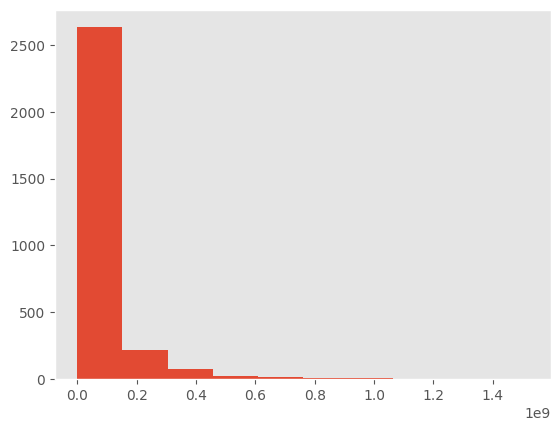

In [93]:
train.revenue.hist(bins = 10,grid = False)

C:\Users\Krishnansh Verma\AppData\Local\Temp\ipykernel_19592\2024668693.py:2: MatplotlibDeprecationWarning:

Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.



Text(0.5, 1.0, 'Distibution of Log transformed Revenue')

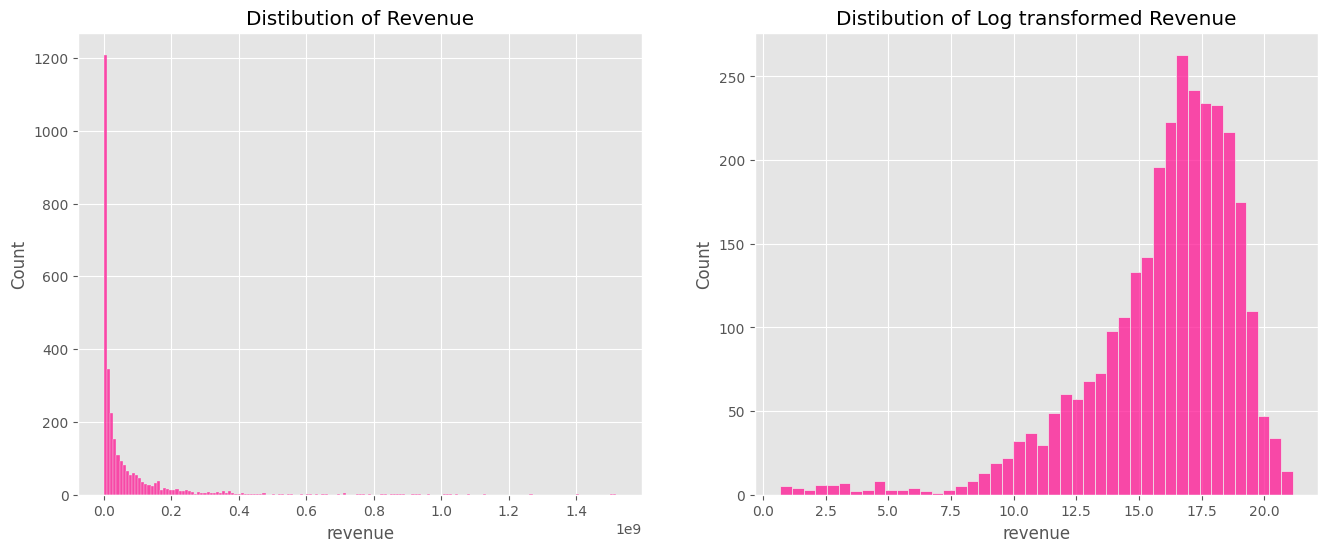

In [94]:
fig,ax = plt.subplots(figsize = (16,6))
plt.subplot(1,2,1)
sns.histplot(train['revenue'],kde = False,color = 'deeppink')
plt.title('Distibution of Revenue')
plt.subplot(1,2,2)
sns.histplot(np.log1p(train['revenue']),kde = False,color = 'deeppink')
plt.title('Distibution of Log transformed Revenue')

In [95]:
train['log_revenue'] = np.log1p(train['revenue'])

This mathematical function helps user to calculate natural logarithmic value of that element + 1.

### Correlation between Film Revenue and Budget

C:\Users\Krishnansh Verma\AppData\Local\Temp\ipykernel_19592\1319574463.py:2: MatplotlibDeprecationWarning:

Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.



Text(0.5, 1.0, 'Log transformed Revenue vs Budget')

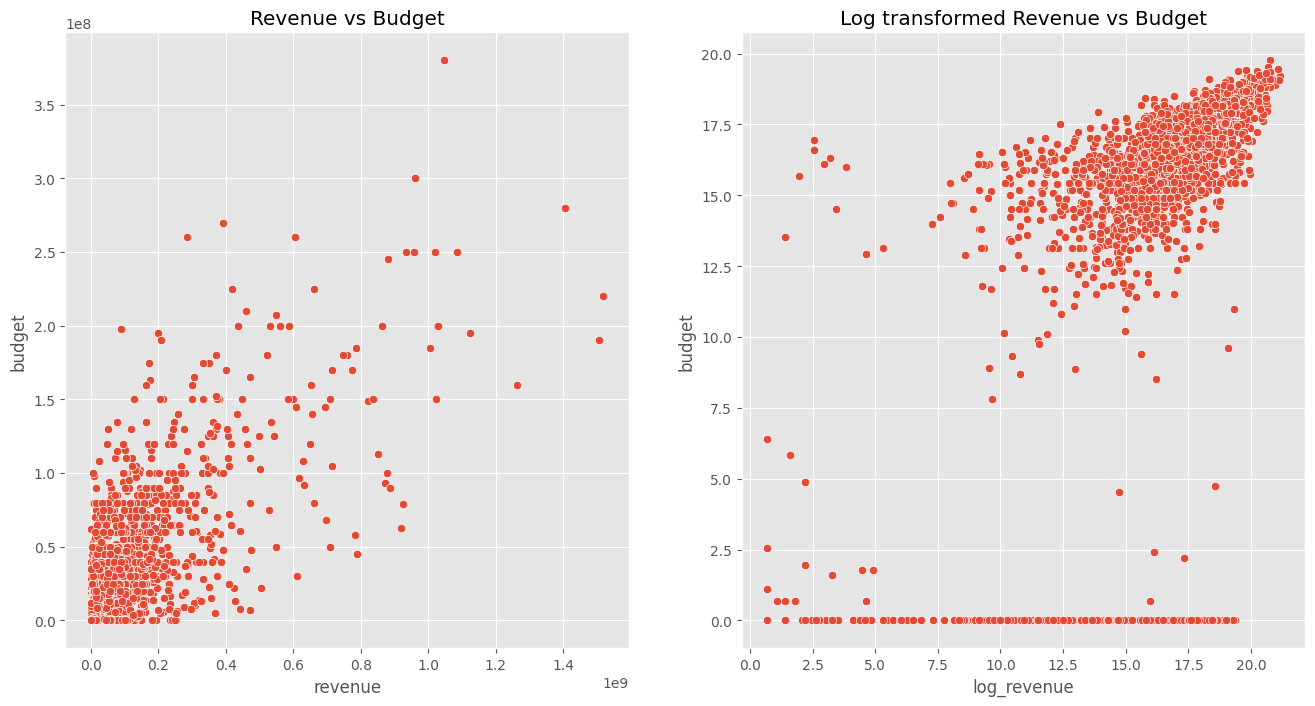

In [96]:
plt.subplots(figsize = (16,8))
plt.subplot(1,2,1)
sns.scatterplot(x = train['revenue'],y = train['budget'])
plt.title('Revenue vs Budget')
plt.subplot(1,2,2)
sns.scatterplot(x = train['log_revenue'],y = np.log1p(train['budget']))
plt.title('Log transformed Revenue vs Budget')

In [97]:
train['log_budget']=np.log1p(train['budget'])
test['log_budget']=np.log1p(test['budget'])

### Effect of Official Homepage on Revenue

In [98]:
train['has_homepage'] = 0
train.loc[train['homepage'].isnull()==False,'has_homepage']=1
test['has_homepage'] = 0
test.loc[test['homepage'].isnull()==False,'has_homepage']=1

Text(0.5, 1.0, 'Comparison of Revenue for films with or without official homepage')

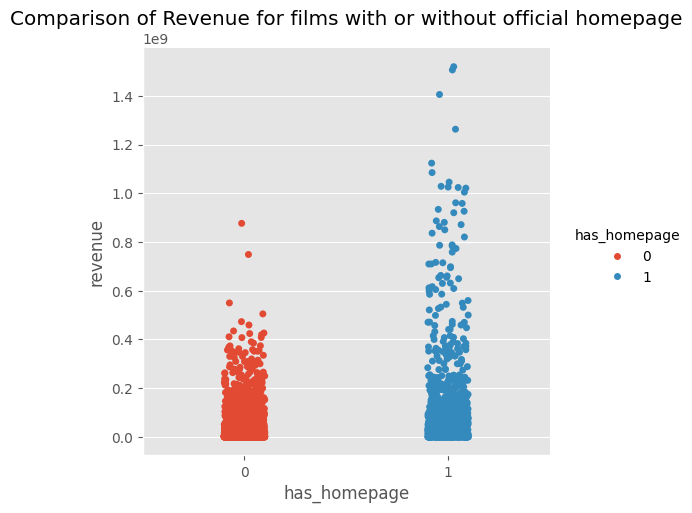

In [99]:
sns.catplot(data = train, x='has_homepage',y='revenue',hue='has_homepage')
plt.title('Comparison of Revenue for films with or without official homepage')

### Distribution of Languages in Films

In [100]:
# top 10 occuring languages in dataset
language_data = train.loc[train['original_language'].isin(train['original_language'].value_counts().head(10).index)]

C:\Users\Krishnansh Verma\AppData\Local\Temp\ipykernel_19592\1535712359.py:2: MatplotlibDeprecationWarning:

Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.



Text(0.5, 1.0, 'Average Log transformed Revenue per Language')

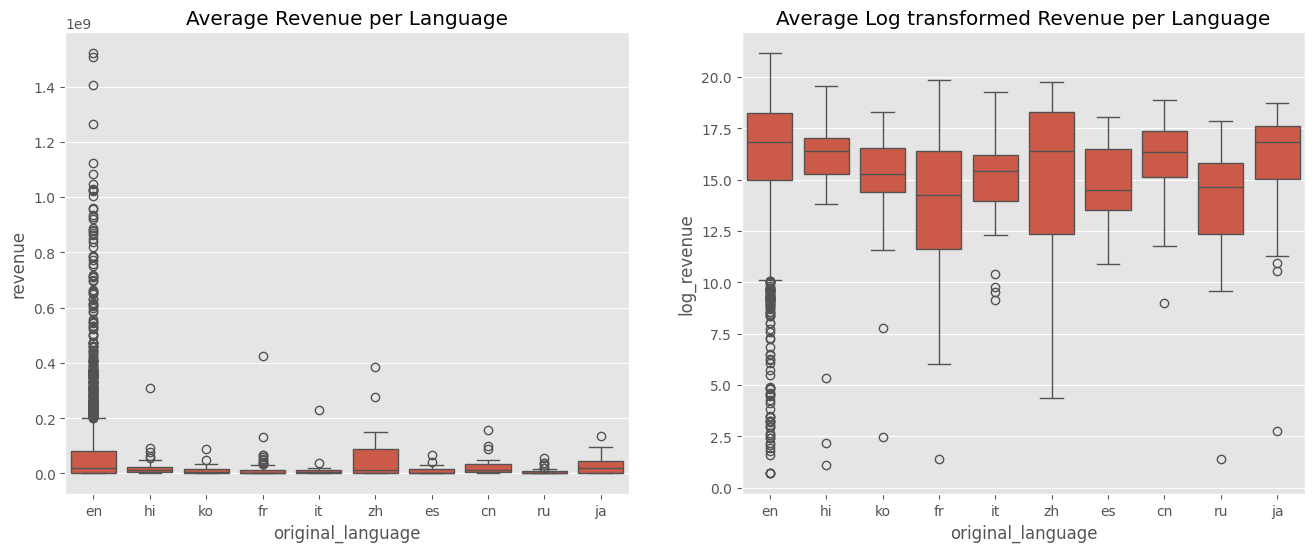

In [101]:
plt.subplots(figsize = (16,6))
plt.subplot(1,2,1)
sns.boxplot(x='original_language',y='revenue',data=language_data)
plt.title('Average Revenue per Language')
plt.subplot(1,2,2)
sns.boxplot(x='original_language',y='log_revenue',data=language_data)
plt.title('Average Log transformed ########ḍ.# dffd df Revenue per Language')

### Plotting their Wordcloud

C:\Users\Krishnansh Verma\AppData\Local\Temp\ipykernel_19592\7952136.py:2: MatplotlibDeprecationWarning:

Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.



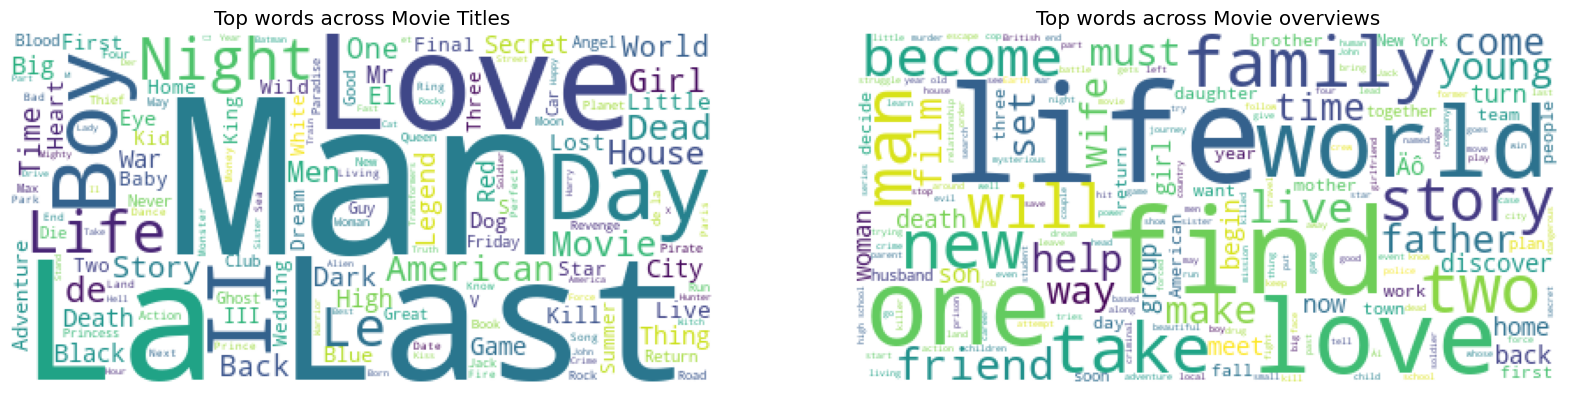

In [102]:
plt.subplots(figsize = (20,20))
plt.subplot(1,2,1)
text = ' '.join(train['original_title'].values)
wordcloud = WordCloud(background_color='white').generate(text)
plt.title('Top words across Movie Titles')
plt.axis('off')
plt.imshow(wordcloud)
plt.subplot(1,2,2)
text = ' '.join(train['overview'].fillna('').values)
wordcloud = WordCloud(background_color='white').generate(text)
plt.title('Top words across Movie overviews')
plt.axis('off')
plt.imshow(wordcloud)

### Impact of Film Description on Revenue

In [104]:
vectorizer = TfidfVectorizer(
    sublinear_tf=True,
    analyzer='word',
    token_pattern=r'\w{1,}',
    ngram_range=(1,2),
    min_df =5
)

In [106]:
overview_text = vectorizer.fit_transform(train['overview'].fillna(''))

In [134]:
overview_text_test = vectorizer.fit_transform(test['overview'].fillna(''))

In [128]:
from sklearn.ensemble import RandomForestRegressor
regressor = RandomForestRegressor(n_estimators=100) #no .of decision trees
regressor.fit(overview_text,train['revenue'])

RandomForestRegressor()